In [33]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
# import src.spatial_attn_lightning as attn_tracking_lightning
from src.spatial_attn_lightning import BinauralAttentionModule 
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def plot_attn_modules(attn_modules, figsize=(8,8), title=None):
    n_attn_blocks = len(attn_modules)  
    if n_attn_blocks == 1:
        fig, axs = plt.subplots(1, figsize=figsize)
        axs = [axs]
    else: 
        fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=figsize)
        axs = axs.ravel()
    x = np.linspace(-5,6, 100)
    
    layer_names = ['Cochleagram' if ix == 0 else f"Layer {ix}" for ix in range(n_attn_blocks)]

    for i, module in enumerate(attn_modules):
        bias = module.bias.item()
        slope = module.slope.item()
        threshold = module.threshold.item() 

        axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
        axs[i].text(1.25, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
        axs[i].set_title(layer_names[i] if title is None else title)
        # axs[i].set_ylim(-0.1,1.1)
        axs[i].set_ylim(-0.1,1.1)
    return fig, axs

## Plot best feature-gain model

Using explicit dim specification for demeaning in audio transforms
Batch in dataloader = False
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
Using dataset BinauralAttentionDataset
OptimizedModule(
  (_orig_mod): BinauralAuditoryAttentionCNN(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (attn0): SimpleAttentionalGain()
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (attn1): SimpleAttentionalGain()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14

/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


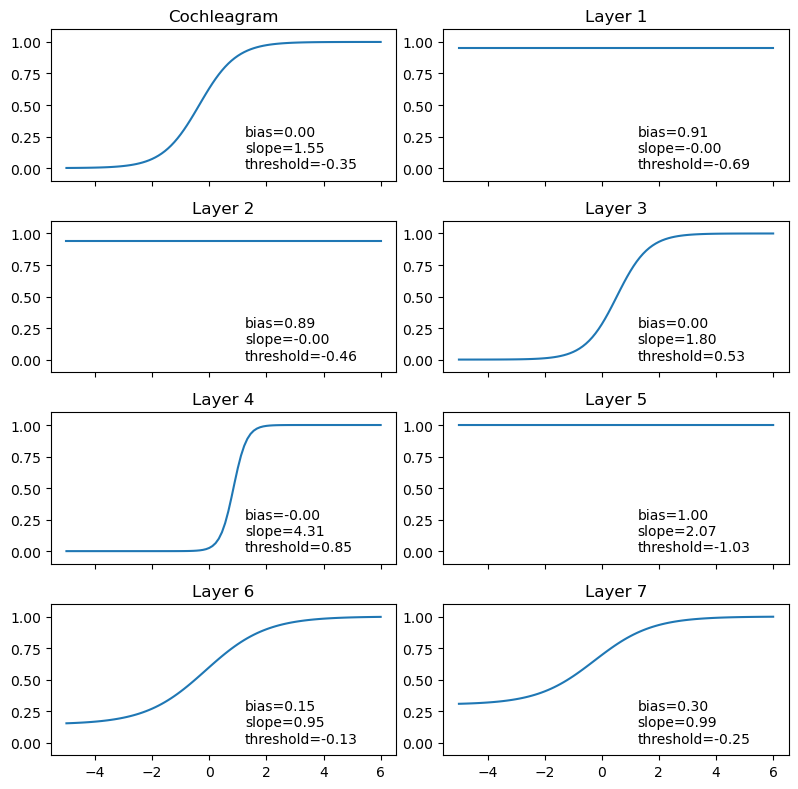

In [104]:
### Get most recent config
config_path = "config/binaural_attn/word_task_v10_main_feature_gain_config.yaml"
ckpt_path = "attn_cue_models/word_task_v10_main_feature_gain_config/checkpoints/epoch=3-step=48037.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

n_attn_blocks = len(attn_modules)   

fig, axs = plot_attn_modules(attn_modules)
plt.tight_layout()

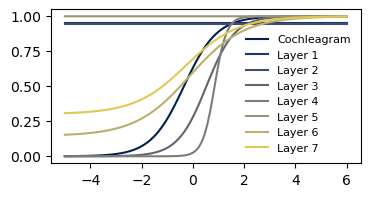

In [105]:
## Plot all attn modules on same panel 

# get sequential color map  
# cmap = plt.get_cmap("viridis")
# cmap = plt.get_cmap("plasma")
# cmap = plt.get_cmap("magma")
cmap = plt.get_cmap("cividis")

fig, ax = plt.subplots(1, figsize=(4, 2))
x = np.linspace(-5, 6, 100)
layer_names = ['Cochleagram' if ix == 0 else f"Layer {ix}" for ix in range(n_attn_blocks)]
for i, module in enumerate(attn_modules):
    bias = module.bias.item()
    slope = module.slope.item()
    threshold = module.threshold.item() 
    ax.plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope), color=cmap(i/n_attn_blocks), label=layer_names[i])

plt.legend(fontsize=8, frameon=False)

## Plot early-only model

Using explicit dim specification for demeaning in audio transforms
Batch in dataloader = False
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: False
coch_affine: True
Using dataset BinauralAttentionDataset
OptimizedModule(
  (_orig_mod): BinauralAuditoryAttentionCNN(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (attn0): SimpleAttentionalGain()
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        

/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


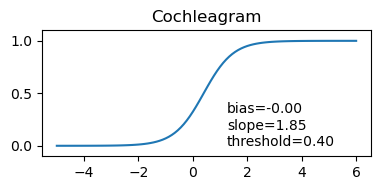

In [34]:
### Get most recent config
config_path = "config/binaural_attn/word_task_early_only_v10.yaml"
ckpt_path = "attn_cue_models/word_task_early_only_v10/checkpoints/epoch=7-step=92753.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

plot_attn_modules(attn_modules, figsize=(4,2))
plt.tight_layout()

## Plot Late-only 

Using explicit dim specification for demeaning in audio transforms
Batch in dataloader = False
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
Using dataset BinauralAttentionDataset
OptimizedModule(
  (_orig_mod): BinauralAuditoryAttentionCNN(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_1):

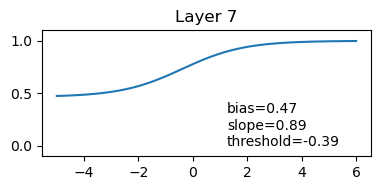

In [35]:
### Get most recent config
config_path = "config/binaural_attn/word_task_late_only_v10.yaml"
ckpt_path = "attn_cue_models/word_task_late_only_v10/checkpoints/epoch=7-step=96753.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

plot_attn_modules(attn_modules, figsize=(4,2), title='Layer 7')
plt.tight_layout()

## Look at gains for all alternate models 

In [99]:
## Setup functions for plotting all gain parameters 
import re 
import os 
from src.util_analysis import get_model_name

def get_ckpt_from_model_dir(model_dir):
    checkpoint_dir = model_dir / 'checkpoints'
    ckpt_paths = sorted(checkpoint_dir.glob("*.ckpt"), key=os.path.getctime)
    if len(ckpt_paths) == 0:
        return None
    ckpt_path = ckpt_paths[-1]
    return ckpt_path

def get_attn_layer_names(state_dict):
    attn_keys = [key for key in state_dict.keys() if 'attn' in key]
    pattern = re.compile(r'attn(\d+)')
    attn_layers = []
    for key in attn_keys:
        match = pattern.search(key)
        if match:
            layer_name = f"attn{match.group(1)}"
            attn_layers.append(layer_name)
        if 'attnfc' in key:
            attn_layers.append('attnfc')
    return np.unique(attn_layers)


def get_key_from_state_dict(state_dict, layer, param):
    # get the key from the state dict
    key = f"model._orig_mod.model_dict.{layer}.{param}"
    param = state_dict[key].item()
    return param  


In [95]:
import os 
from src.util_analysis import get_model_name

all_v10_models = list(Path("attn_cue_models").glob("word_task_v10*"))
main_fba_models = [path for path in all_v10_models if ('main' in path.stem or 'arch' in path.stem) and not '50Hz' in path.stem]


ckpt_path = get_ckpt_from_model_dir(main_fba_models[0])
ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

# get human readable model name and checkpoint for each model 
good_model_dict = {}
for model in main_fba_models:
    # get the checkpoint path
    ckpt_path = get_ckpt_from_model_dir(model)
    # if the checkpoint exists, store state dict as value and human-readable model name as key
    if ckpt_path is not None:
        model_name = get_model_name(model.stem)
        good_model_dict[model_name] = torch.load(ckpt_path, map_location=torch.device('cpu'))['state_dict']




In [ ]:


attn_layers = get_attn_layer_names(ckpt['state_dict'])
attn0_bias = get_key_from_state_dict(ckpt['state_dict'], attn_layers[0], 'slope')
s


## implement get_key_from_state_dict without looping over keys


1.902523159980774

In [97]:
attn_modules

[tensor([-0.4523]),
 tensor([-0.7161]),
 tensor([1.1956]),
 tensor([-0.3878]),
 tensor([0.8228]),
 tensor([-1.2859]),
 tensor([-1.3390]),
 tensor([-0.6738]),
 tensor([-0.1808]),
 tensor([-0.0918]),
 tensor([-0.1273])]

In [115]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', s)]

model_plot_order  = sorted(good_model_dict.keys(), key=natural_sort_key)
model_plot_order  = [model_plot_order[-1]] + model_plot_order[:-1]
model_plot_order

['Feature-gain main',
 'Feature-gain alt v1',
 'Feature-gain alt v2',
 'Feature-gain alt v4',
 'Feature-gain alt v6',
 'Feature-gain alt v7',
 'Feature-gain alt v8',
 'Feature-gain alt v9',
 'Feature-gain alt v10',
 'Feature-gain alt v12']

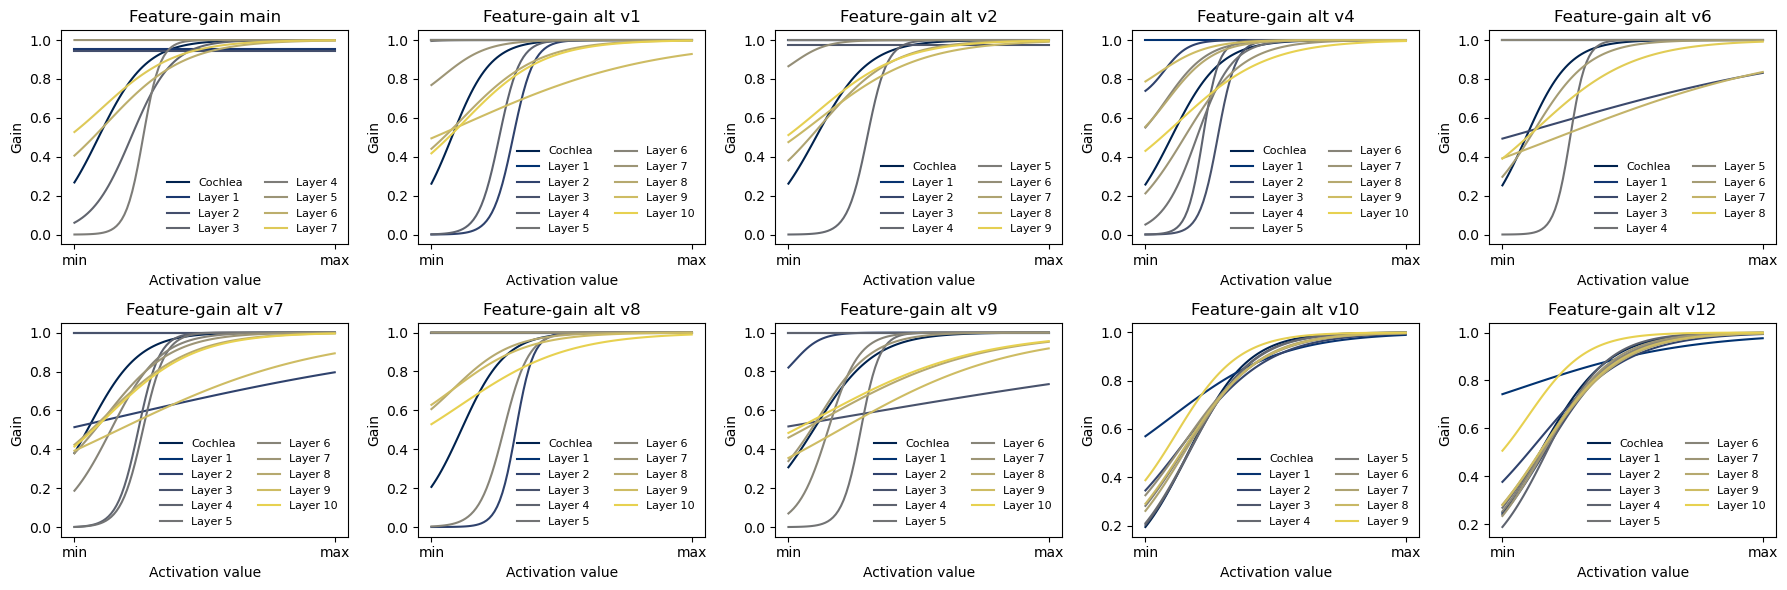

In [127]:
## Plot all attn modules on same panel 

cmap = plt.get_cmap("cividis")

n_models = len(good_model_dict)

n_columns = 5 
n_rows = 2


fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 6))
axes = axes.ravel()


x = np.linspace(-1, 6, 100)
for i, model_name in enumerate(model_plot_order):
    state_dict = good_model_dict[model_name]
    attn_layers = get_attn_layer_names(state_dict)
    n_layers = len(attn_layers)
    layer_names = ['Cochlea' if ix == 0 else f"Layer {ix}" for ix in range(n_layers)]

    for j, (l_name, layer) in enumerate(zip(layer_names, attn_layers)):
        bias = get_key_from_state_dict(state_dict, layer, 'bias')
        slope = get_key_from_state_dict(state_dict, layer, 'slope')
        threshold = get_key_from_state_dict(state_dict, layer, 'threshold')
        axes[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope), color=cmap(j/n_layers), label=l_name)
        axes[i].set_title(model_name)
        axes[i].legend(fontsize=8, ncol=2, frameon=False)
        axes[i].set_xticks([-1, 6])
        axes[i].set_xticklabels(['min', 'max'])
        axes[i].set_xlabel('Activation value')
        axes[i].set_ylabel('Gain')

        
plt.tight_layout()

